# Classification: Churn Rate Analysis
##### Owen Lindsey
##### Professor Majumdar
##### AIT-110: Statistical Learning Theory
##### Grand Canyon University
##### Date: Feb 1, 2026

## Classification and Resampling Techinques

---

### ***Part 1:*** Understanding Classification Techniques

---

***Variables:*** 



1. Churn (dependent variable): Binary yes or no classification. 
2. Tenure (independent variable): The amount of time in months the customer has stayed with the company. 
3. MonthlyCharges (independent variable): The monthly charges paid by the customer
4. TotalCharges (independent variable): The total charges paid by the customer. 


***Next steps:***


- Fit a logistic regression model using the above variables. Interpret the data produced. I will prove which variables significantly predict churn.
- Apply a K-Nearest-Neighbors algorithim using k=5. 

---

### ***Part 2:*** Resampling Methods and Model Improvement 

---

***Steps***

1. Perform 5-fold cross-validation on both classification models.
2. Report the avg accuracy and standard deviation of the models across the folds. 
3. Interpret the results: Which model predicted the best across each fold. 
4. Apply bootstrap resampling(with 1,000 iterations) to the logistic regression model. 
5. Compare the performance (based on accuracy) between the original vs the bootstrap method. How has the bootstrapped method affected the models reliablilty. 

---

### ***Part 3:*** Model Evaluation

---

***Steps***

1.    For each model (logistic regression and KNN), create a confusion matrix to evaluate the performance of the model on the test set.
2.    Interpret the confusion matrix in terms of true positives, false positives, true negatives, and false negatives for each model.
Accuracy, Sensitivity, and Specificity:
3.    Calculate the accuracy, sensitivity (recall), and specificity of each model using the confusion matrix.
4.    Compare the performance metrics across the models and determine which model is most effective at predicting customer churn.
ROC Curve and AUC:
5.    Plot the ROC curve for each classification model.
6.    Calculate the area under the curve (AUC) for each model and explain what the AUC represents in the context of model performance.
Model Selection and Final Recommendation:
7.    Based on the results of the confusion matrix, accuracy, sensitivity, specificity, and AUC, recommend the best model for predicting customer churn. Provide a rationale for your recommendation.

In [39]:
# Importing the necessary libraries
# pandas is used to read the excel file
# os is used to navigate the file system


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler
import numpy as np

# Path to the excel file
customer_churn_dataset = 'data/Telco_customer_churn.xlsx'

# Read the excel file
# sheet_name='Data' is the name of the sheet in the excel file
df = pd.read_excel(customer_churn_dataset, sheet_name='Telco_Churn')

# Display the first 10 rows of the dataframe
df.head(10)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
5,4190-MFLUW,1,United States,California,Los Angeles,90020,"34.066367, -118.309868",34.066367,-118.309868,Female,...,Month-to-month,No,Credit card (automatic),55.20,528.35,Yes,1,78,5925,Competitor offered higher download speeds
6,8779-QRDMV,1,United States,California,Los Angeles,90022,"34.02381, -118.156582",34.023810,-118.156582,Male,...,Month-to-month,Yes,Electronic check,39.65,39.65,Yes,1,100,5433,Competitor offered more data
7,1066-JKSGK,1,United States,California,Los Angeles,90024,"34.066303, -118.435479",34.066303,-118.435479,Male,...,Month-to-month,No,Mailed check,20.15,20.15,Yes,1,92,4832,Competitor made better offer
8,6467-CHFZW,1,United States,California,Los Angeles,90028,"34.099869, -118.326843",34.099869,-118.326843,Male,...,Month-to-month,Yes,Electronic check,99.35,4749.15,Yes,1,77,5789,Competitor had better devices
9,8665-UTDHZ,1,United States,California,Los Angeles,90029,"34.089953, -118.294824",34.089953,-118.294824,Male,...,Month-to-month,No,Electronic check,30.20,30.2,Yes,1,97,2915,Competitor had better devices


In [40]:
print(df.columns)

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')


<Axes: xlabel='Churn Label', ylabel='Tenure Months'>

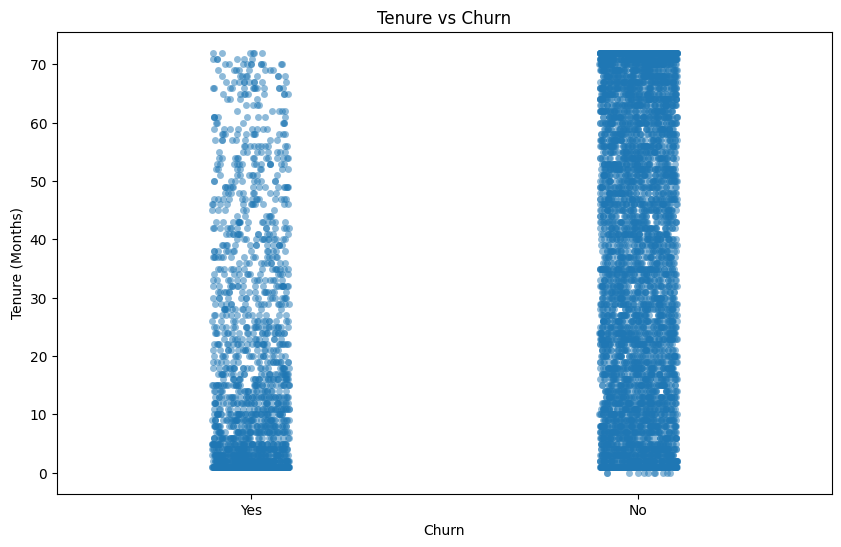

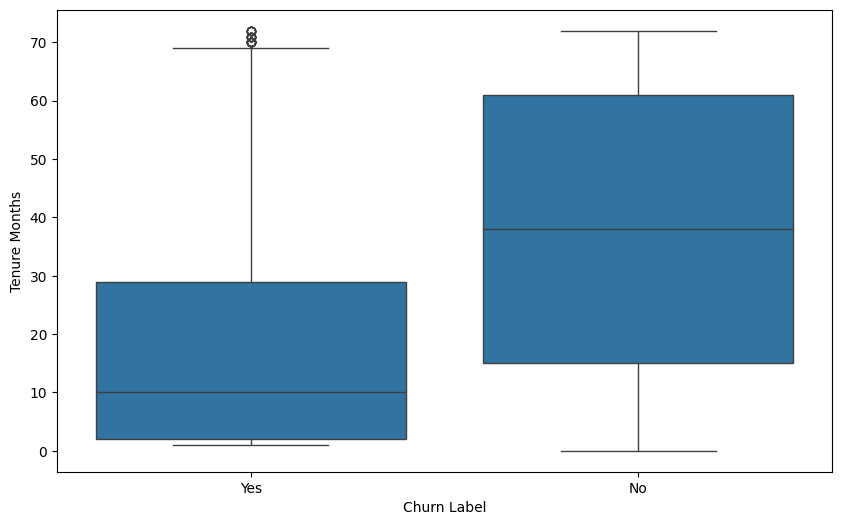

In [41]:
features = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Create a scatter plot of tenure vs churn
# Create a strip plot of tenure vs churn
plt.figure(figsize=(10, 6))
sns.stripplot(x='Churn Label', y='Tenure Months', data=df, alpha=0.5)
plt.title('Tenure vs Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')

# Create a box plot of monthly charges vs churn
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn Label', y='Tenure Months', data=df)



### Data Preparation
Prepare the features (X) and target variable (y) for modeling.

In [42]:
# Select features and target
# Using the correct column names from the dataset
X = df[['Tenure Months', 'Monthly Charges', 'Total Charges']].copy()

# Convert Total Charges to numeric (it may have some non-numeric values)
X['Total Charges'] = pd.to_numeric(X['Total Charges'], errors='coerce')

# Drop rows with missing values
X = X.dropna()

# Target variable: Churn Value (1 = churned, 0 = stayed)
y = df.loc[X.index, 'Churn Value']

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features (important for KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"Churn rate in training set: {y_train.mean():.2%}")

Training set size: 5625
Test set size: 1407
Churn rate in training set: 26.20%


## Part 1: Classification Models

In [43]:
# ============================================
# LOGISTIC REGRESSION MODEL (Complete Example)
# ============================================

# Create and train the model
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Make predictions
y_pred_log = log_reg.predict(X_test_scaled)

# Evaluate
print("=== Logistic Regression Results ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

# View coefficients (shows which variables influence churn)
print("\nFeature Coefficients:")
for feature, coef in zip(X.columns, log_reg.coef_[0]):
    print(f"  {feature}: {coef:.4f}")

=== Logistic Regression Results ===
Accuracy: 0.7932

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.92      0.87      1012
           1       0.70      0.46      0.55       395

    accuracy                           0.79      1407
   macro avg       0.76      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407


Feature Coefficients:
  Tenure Months: -1.7077
  Monthly Charges: 0.8905
  Total Charges: 0.3994


In [ ]:
# ============================================
# K-NEAREST NEIGHBORS MODEL
# ============================================

# Create and train the KNN model with k=5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print("=== K-Nearest Neighbors Results ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

=== K-Nearest Neighbors Results ===
Accuracy: 0.7640

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.88      0.84      1012
           1       0.60      0.48      0.53       395

    accuracy                           0.76      1407
   macro avg       0.71      0.68      0.69      1407
weighted avg       0.75      0.76      0.75      1407



## Part 2: Resampling Methods

In [45]:
# ============================================
# 5-FOLD CROSS-VALIDATION (Example for Logistic Regression)
# ============================================

# Cross-validation for Logistic Regression
cv_scores_log = cross_val_score(log_reg, X_train_scaled, y_train, cv=5, scoring='accuracy')

print("=== Logistic Regression Cross-Validation ===\n")
print(f"Fold Accuracies: {cv_scores_log}\n")
print(f"Mean Accuracy: {cv_scores_log.mean():.4f}\n")
print(f"Standard Deviation: {cv_scores_log.std():.4f}\n")
print(classification_report(y_test, y_pred_knn))

=== Logistic Regression Cross-Validation ===

Fold Accuracies: [0.79466667 0.78133333 0.76088889 0.78755556 0.79733333]

Mean Accuracy: 0.7844

Standard Deviation: 0.0130

              precision    recall  f1-score   support

           0       0.81      0.88      0.84      1012
           1       0.60      0.48      0.53       395

    accuracy                           0.76      1407
   macro avg       0.71      0.68      0.69      1407
weighted avg       0.75      0.76      0.75      1407



In [ ]:
# ============================================
# 5-FOLD CROSS-VALIDATION FOR KNN
# ============================================

# Perform cross-validation on KNN model
cross_val_scores_knn = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"Mean Accuracy: {cross_val_scores_knn.mean():.4f}")
print(f"Standard Deviation: {cross_val_scores_knn.std():.4f}")


Mean Accuracy: 0.7660
Standard Deviation: 0.0076


In [ ]:
# ============================================
# BOOTSTRAP RESAMPLING
# ============================================
# Apply bootstrap resampling with 1,000 iterations to logistic regression
# Bootstrap: randomly sample with replacement, train, evaluate, repeat

n_iterations = 1000
bootstrap_accuracies = []

for i in range(n_iterations):
    # Sample with replacement (same size as training set)
    indices = np.random.choice(len(X_train_scaled), size=len(X_train_scaled), replace=True)
    X_boot = X_train_scaled[indices]
    y_boot = y_train.iloc[indices]
    
    # Fit a new LogisticRegression model and evaluate
    new_log_reg = LogisticRegression(random_state=42, max_iter=1000)
    new_log_reg.fit(X_boot, y_boot)
    y_pred_boot = new_log_reg.predict(X_test_scaled)
    bootstrap_accuracies.append(accuracy_score(y_test, y_pred_boot))

# After the loop, print:
# - Mean bootstrap accuracy
# - Standard deviation
# - Compare to original accuracy
print(f"Mean Bootstrap Accuracy: {np.mean(bootstrap_accuracies):.4f}")
print(f"Standard Deviation: {np.std(bootstrap_accuracies):.4f}")
print(f"Original Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")

Mean Bootstrap Accuracy: 0.7933
Standard Deviation: 0.0021
Original Accuracy: 0.7932


## Part 3: Model Evaluation

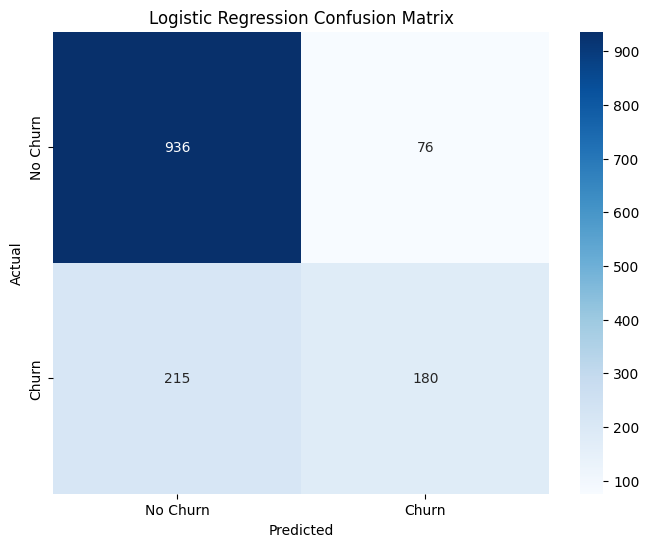


True Negatives: 936
False Positives: 76
False Negatives: 215
True Positives: 180


In [48]:
# ============================================
# CONFUSION MATRIX (Example for Logistic Regression)
# ============================================

cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Extract values
tn, fp, fn, tp = cm_log.ravel()
print(f"\nTrue Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")

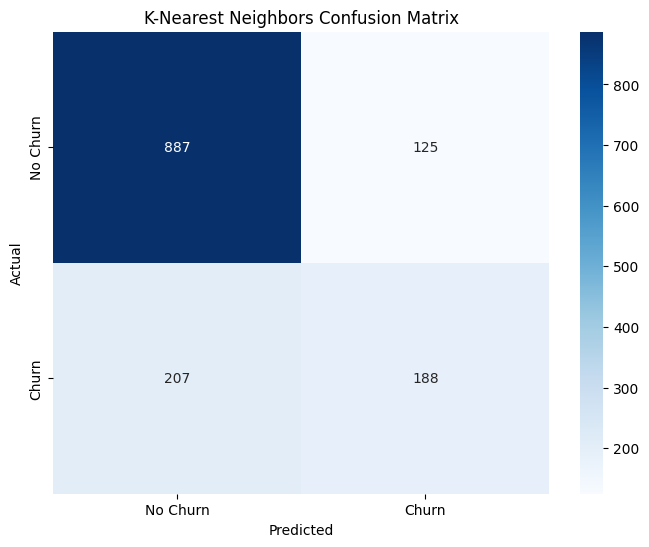


True Negatives: 887
False Positives: 125
False Negatives: 207
True Positives: 188


In [ ]:
# ============================================
# CONFUSION MATRIX FOR KNN
# ============================================

# Create confusion matrix for KNN model
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('K-Nearest Neighbors Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Extract values
tn_knn, fp_knn, fn_knn, tp_knn = cm_knn.ravel()
print(f"\nTrue Negatives: {tn_knn}")
print(f"False Positives: {fp_knn}")
print(f"False Negatives: {fn_knn}")
print(f"True Positives: {tp_knn}")


In [50]:
# ============================================
# ACCURACY, SENSITIVITY, SPECIFICITY (Example)
# ============================================

# Using the confusion matrix values from Logistic Regression
accuracy = (tp + tn) / (tp + tn + fp + fn)
sensitivity = tp / (tp + fn)  # Also called Recall
specificity = tn / (tn + fp)

print("=== Logistic Regression Metrics ===")
print(f"Accuracy: {accuracy:.4f}")
print(f"Sensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")

=== Logistic Regression Metrics ===
Accuracy: 0.7932
Sensitivity (Recall): 0.4557
Specificity: 0.9249


In [ ]:
# ============================================
# KNN METRICS
# ============================================

# Calculate accuracy, sensitivity, and specificity for KNN
accuracy_knn = (tp_knn + tn_knn) / (tp_knn + tn_knn + fp_knn + fn_knn)
sensitivity_knn = tp_knn / (tp_knn + fn_knn)
specificity_knn = tn_knn / (tn_knn + fp_knn)

print("=== K-Nearest Neighbors Metrics ===")
print(f"Accuracy: {accuracy_knn:.4f}")
print(f"Sensitivity (Recall): {sensitivity_knn:.4f}")
print(f"Specificity: {specificity_knn:.4f}")

=== K-Nearest Neighbors Metrics ===
Accuracy: 0.7640
Sensitivity (Recall): 0.4759
Specificity: 0.8765


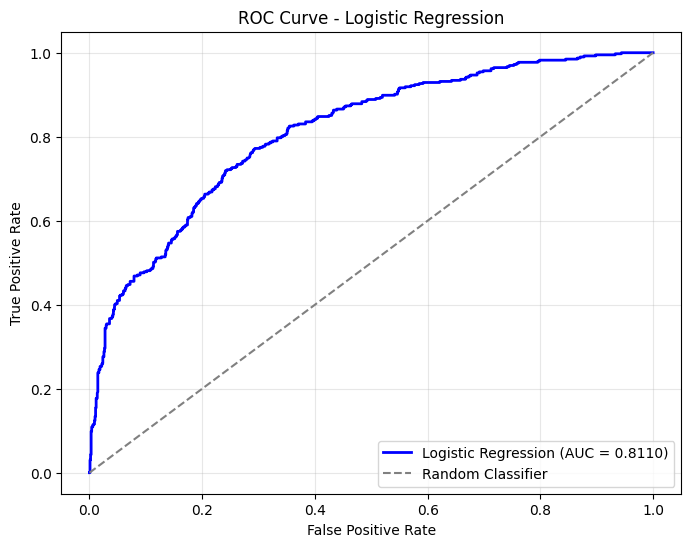

AUC Score: 0.8110

Interpretation: AUC represents the probability that the model ranks
a randomly chosen positive instance higher than a randomly chosen negative one.


In [52]:
# ============================================
# ROC CURVE AND AUC (Example for Logistic Regression)
# ============================================

# Get probability predictions (needed for ROC curve)
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC curve
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
auc_log = auc(fpr_log, tpr_log)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, color='blue', lw=2, label=f'Logistic Regression (AUC = {auc_log:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

print(f"AUC Score: {auc_log:.4f}")
print("\nInterpretation: AUC represents the probability that the model ranks")
print("a randomly chosen positive instance higher than a randomly chosen negative one.")

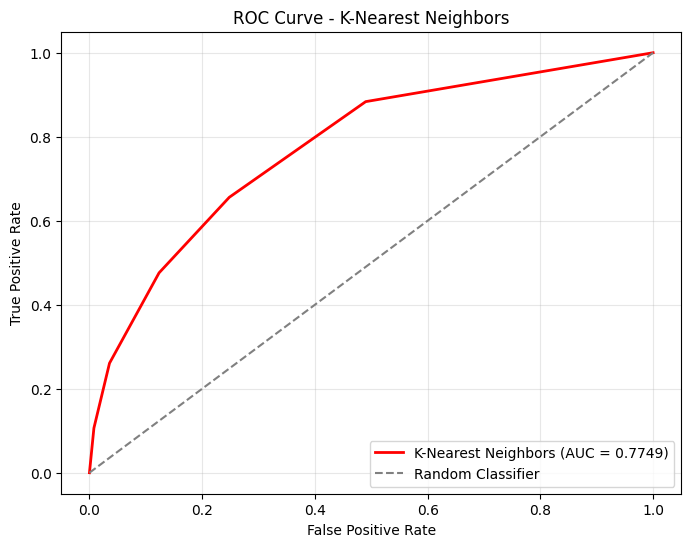

AUC Score: 0.7749


In [ ]:
# ============================================
# ROC CURVE FOR KNN
# ============================================

# Get probability predictions and calculate ROC curve
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
auc_knn = auc(fpr_knn, tpr_knn)

plt.figure(figsize=(8, 6))
plt.plot(fpr_knn, tpr_knn, color='red', lw=2, label=f'K-Nearest Neighbors (AUC = {auc_knn:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - K-Nearest Neighbors')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

print(f"AUC Score: {auc_knn:.4f}")


## Final Recommendation 


1. Which model performed better overall? Why?

The logistic regression model performed best. Even after the fold analysis and bootstrapping, logistic regression maintained higher accuracy (79.32% vs 76.40%) and a higher AUC score (0.8110), indicating better overall discriminative ability. The bootstrap results showed the model is stable (std = 0.0022). While KNN had slightly better sensitivity (47.6% vs 45.57%), logistic regression's superior specificity (92.49%) and overall accuracy make it the better choice for predicting customer churn. 

2. Consider the trade-offs between sensitivity and specificity for churn prediction

In churn prediction, there's a trade-off between sensitivity and specificity. Our model has high specificity (92.49%) but lower sensitivity (45.57%), meaning we're good at identifying loyal customers but miss over half of the actual churners. If we adjusted the classification threshold to catch more churners (higher sensitivity), we'd also incorrectly flag more loyal customers as at-risk (lower specificity). For a business focused on retention, increasing sensitivity might be preferred, it's better to intervene with some loyal customers than to miss potential churners entirely.

3. What are the business implications of false positives vs false negatives in this context?

In customer churn prediction, false negatives are typically more costly than false positives. A false negative means we fail to identify a customer who churns—resulting in lost revenue and the expense of acquiring a new customer to replace them. A false positive means we spend retention resources on a customer who wasn't going to leave, which wastes budget but keeps the customer happy. Given that customer acquisition costs are often 5-7x higher than retention costs, businesses should prioritize minimizing false negatives (higher sensitivity), even if it means more false positives. Our model's low sensitivity (45.57%) means we're missing over half of potential churners.